In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

cmap = matplotlib.colormaps.get_cmap('magma')
size=12
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,      
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)

data_dir = 'raw_data_kymos/'

from SVD_analysis.src.fitting_utils import fit_function, allometric, arrhenius

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# Load data (SVD output)

In [2]:
df = pd.read_csv('SVD_results/result_parameters_chronic.csv',index_col=[0, 1, 2])
df_cycling = pd.read_csv('SVD_results/result_parameters_cycling.csv',index_col=[0, 1, 2])
df_hilbert = pd.read_csv('SVD_results/result_parameters_cycling_6h.csv',index_col=[0, 1, 2])


# Phase gradient: beta and x0

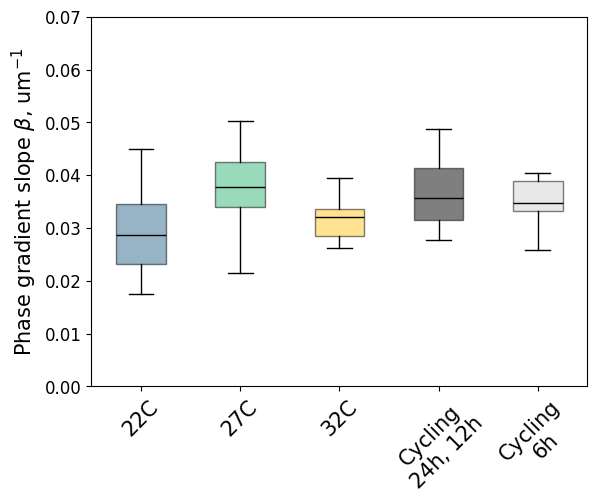

In [3]:
all_betas  = []
colors =('tab:blue', 'tab:green', 'gold', 'k', 'lightgrey')
colors = ('#31688e', '#35b779', '#ffc726', 'k', 'lightgrey')

for i, temp in enumerate((22, 27, 32)):
    all_betas.append(np.array(df.loc[ (df['Temp']==temp) & (df['good_fit'] == True) & (df['beta'] >0 ),'beta']))

all_betas.append(np.array(df_cycling['beta'] [(df_cycling['good_fit'] == True) & (df_cycling['x0'] > 70)]))
all_betas.append(np.array(df_hilbert['beta'] [(df_hilbert['good_fit'] == True)]))
# all_betas = [betas[~np.isnan(betas)] for betas in all_betas]
# all_betas = [betas[betas<0.022] for betas in all_betas]    # to remove two outliers in cycling

bp = plt.boxplot(all_betas, patch_artist=True, medianprops=dict(color='k'), showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

plt.ylim((0, 0.07))
plt.xticks(np.arange(len(all_betas))+1, ('22C', '27C', '32C', 'Cycling\n24h, 12h', 'Cycling\n6h'), rotation=45, fontsize=15)
plt.ylabel(r'Phase gradient slope $\beta$, um$^{-1}$', fontsize=15)
plt.show()

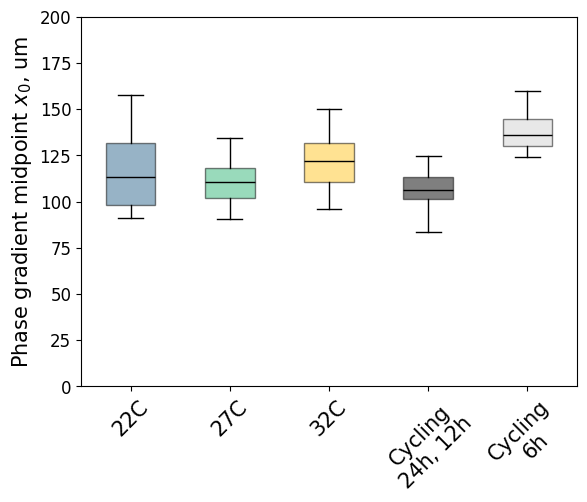

In [4]:
all_x0  = []
colors =('tab:blue', 'tab:green', 'gold', 'k', 'lightcoral')
colors = ('#31688e', '#35b779', '#ffc726', 'k', 'lightgrey')

for temp in (22, 27, 32):
    all_x0.append(np.array(df.loc[ (df['Temp']==temp) & (df['good_fit'] == True),'x0']))

all_x0.append(np.array(df_cycling['x0'] [(df_cycling['good_fit'] == True) & (df_cycling['x0'] > 70)]))
all_x0.append(np.array(df_hilbert['x0']) [(df_hilbert['good_fit'] == True)])

bp = plt.boxplot(all_x0, patch_artist=True, medianprops=dict(color='k'), showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

plt.ylim((0, 200))
plt.xticks(np.arange(len(all_x0))+1, ('22C', '27C', '32C', 'Cycling\n24h, 12h', 'Cycling\n6h'), rotation=45, fontsize=15)
plt.ylabel(r'Phase gradient midpoint $x_0$, um', fontsize=15)
plt.show()

# Parameters as a function of temperature

In [5]:
k_coef = {}

units = {'omega0': ' ${min}^{-1}$', 'v_f': ' ${um/min}$', 'v_tb': ' ${um/min}$', 'T0*v_f': ' ${um}$',
         'beta': ' ${um}^{-1}$', 'alpha': ' ${min}^{-1}$', 'alpha_cycle': '', 'Fit resid (% cycle)': '% cycle', 'Amp':'',
         'kappa_c': ' $\pi$', 'kappa': ' $\pi/{min}$', 'deltaphi_init': ' $\pi$', 'lambda_f': ' ${um}$', 'lambda_tb': ' ${um}$'
}

symbols = {'omega0': '$\omega$', 'v_f': '$v_f$', 'v_tb': '$v_{tb}$', 'T0*v_f': '$\lambda$',
         'beta': r'$\beta$', 'alpha': r'$\alpha$', 'alpha_c': r'$\alpha_c$', 'Amp': r'$A$',
           'lambda_f': r'$\lambda_f$', 'lambda_tb': r'$\lambda_{tb}$',
           'resid_cycle': 'Residual (% cycle)'
}

err_power = 0
Tref = 27. #

def plot_results(results_df, pars_to_plot, ylims, print_avg=False, plot_k=True, k5=True, all_fit=False):
    npars = len(pars_to_plot)
    fig,ax = plt.subplots(1,npars, figsize=((4 * npars+0.1, 4)))
    if npars == 1:
        ax = [ax]
    for par_ind, par in enumerate(pars_to_plot):

        avgs = np.zeros(3)
        errs = np.zeros(3)
        for iT, Temp in enumerate((22., 27., 32.)):
            results = np.asarray(results_df.loc[(results_df['Temp'] == Temp) & results_df['good_fit'], par]).astype('float')
            if par+' err' in results_df:
                errors = np.asarray(results_df.loc[(results_df['Temp'] == Temp) & results_df['good_fit'], par+' err']).astype('float')
                ind = np.where(~np.isnan(results))
                errors = errors[~np.isnan(results)]
                results = results[~np.isnan(results)]
                s = 1./errors**err_power
                avg = np.average(results, weights=1./errors**err_power)
                std = np.sqrt(np.average((results - avg)**2, weights=1./errors**err_power))
            else:
                errors = np.ones(len(results))
                ind = np.where(~np.isnan(results))
                errors = errors[~np.isnan(results)]
                results = results[~np.isnan(results)]
                avg = np.mean(results)
                std = np.std(results)
                s = np.ones(len(results))

            avgs[iT] = avg
            errs[iT] = std
            Temps = Temp*np.ones(len(results))
            s *= 85./np.mean(s)
            colors = [color for color in np.asarray(results_df.loc[results_df['Temp'] == Temp, 'color'])[ind[0]]]
            ax[par_ind].scatter(Temp + .8*(np.random.rand(len(results))-0.5), results, s=s, alpha=0.3,
                                c=colors, zorder=1)

            # ax[par_ind].scatter(Temp, avg, c='k', marker='s', alpha=0.3)
            ax[par_ind].errorbar(Temp, avg, yerr=std, fmt="s", c='k', alpha=1, markersize=5, lw=2, zorder=2)

        if print_avg:
            print(par+": "+str(avgs)+' with errs '+str(errs))

        results = np.asarray(results_df.loc[:, par]).astype('float')
        Temps = np.asarray(results_df.loc[:, 'Temp']).astype('float')
        if par+' err' in results_df:
            errors = np.asarray(results_df.loc[:, par+' err']).astype('float')
            errors = errors[~np.isnan(results)]
            Temps = Temps[~np.isnan(results)]
            results = results[~np.isnan(results)]
        else:
            errors = np.ones(len(results))
            errors = errors[~np.isnan(results)]
            Temps = Temps[~np.isnan(results)]
            results = results[~np.isnan(results)]

        #  P(T) = fit[0]*(T-Tref) + fit[1] = fit[1]*(1 + fit[0]/fit[1] * (T-Tref))
        #  k = fit[0]/fit[1]
        linear_fit, pcov = np.polyfit(Temps-Tref, results, 1, w=1/errors**err_power, cov=True)
        k = linear_fit[0]/linear_fit[1]
        perr = np.sqrt(np.diag(pcov))
        k_err = np.sqrt( (perr[0]/linear_fit[1])**2 + (k/linear_fit[1]*perr[1])**2)

        #  P(T) = fit[0]*T + fit[1] = fit[0]*(T + fit[1]/fit[0])
        # Tc = - fit[1]/fit[0]
        linear_fit_Tc, pcov_Tc = np.polyfit(Temps, results, 1, w=1/errors**err_power, cov=True)
        Tc = - linear_fit_Tc[1]/linear_fit_Tc[0]
        #
        print('Tc '+par+':', Tc)

        if all_fit:
            allometric_fit, allo_pars, allo_cov = fit_function(allometric, Temps/Tref, results)
            print('Allometric model:', allo_pars)

            Temps_K = Temps + 273.15
            Tref_K = Tref + 273.15
            arrhenius_fit, arr_pars, arr_cov = fit_function(arrhenius, Temps_K/Tref_K, results, p0=(linear_fit[1], 20) )
            print('Arrhenius model:', arr_pars)

        if plot_k:
            if k5:
                k_label = '$k_5$ = '+str(round(k*5*100, 1))+'%'
            else:
                k_label = '$k$ = '+str(round(k, 4))

            Tc_label = '$T_c$ = '+str(round(Tc, 2))+'$^{\circ}C$'

            Temps_plot = np.linspace(20, 34, 51)

            ax[par_ind].plot(Temps_plot, linear_fit[0]*(Temps_plot-Tref)+linear_fit[1],
                            '--', c = 'grey', alpha=1, label=k_label, lw=1)

            if all_fit:
                allo_label = '$b$ = '+str(round(allo_pars[1], 2))
                arr_label = '$E_a$ = '+str(round(arr_pars[1], 1))+' $k_{B}T_{ref}$'
                ax[par_ind].plot(Temps_plot, allometric(Temps_plot/Tref, *allo_pars), '-', c='grey', alpha=1, lw=1, label=allo_label)
                ax[par_ind].plot(Temps_plot, arrhenius( (Temps_plot+273.15)/Tref_K, *arr_pars), '-', c='k', alpha=1, lw=1, label=arr_label)

        k_coef[par] = (k, k_err)

        p27 = linear_fit[1]
        print(par, 'p(27) =', p27, '; k =', k)

        avg = np.average(results[Temps==Tref], weights=1./(errors[Temps==Tref])**err_power)
        avg = p27

        ax[par_ind].plot(np.linspace(19,35,11), avg*np.ones(11), '-', c='k', alpha=0.5, zorder=0, lw=1)
        ax[par_ind].set_xticks([22, 27, 32])

        if par in symbols:
            label = symbols[par]
        else:
            label = par

        if par in units:
            unit = units[par]
        else:
            unit = ''
        if par in ylims:
            ax[par_ind].set_ylim(ylims[par])
            # ax[par_ind].set_ylabel(par)

            if unit != '':
                ax[par_ind].set_ylabel(label +','+unit, fontsize = 15)
            else:
                ax[par_ind].set_ylabel(label, fontsize = 15)

        else:
            ax[par_ind].set_ylim((0., 2*avg)) ##############
            ax[par_ind].set_yticks(np.arange(0., 2.01, 0.5)*avg)
            ax[par_ind].set_yticklabels(np.arange(0., 2.01, 0.5))
            ax[par_ind].set_ylabel(label +' / '+str(np.round(avg, 3))+unit, fontsize = 15)


        string = '\frac{' + label +'}{'+str(np.round(avg, 3))+unit+'}'
        if plot_k:
            ax[par_ind].legend(frameon=False, fontsize=14, loc='lower right')


         # ___________________ fit 22 - 27
        # print()
        # print('21-27')
        # results = np.asarray(results_df.loc[:, par])[results_df.loc[:, 'Temp'] != 32].astype('float')
        # Temps = np.asarray(results_df.loc[:, 'Temp'])[results_df.loc[:, 'Temp'] != 32].astype('float')
        # if par+' err' in results_df:
        #     errors = np.asarray(results_df.loc[:, par+' err'])[results_df.loc[:, 'Temp'] != 32].astype('float')
        #     errors = errors[~np.isnan(results)]
        #     Temps = Temps[~np.isnan(results)]
        #     results = results[~np.isnan(results)]
        # else:
        #     errors = np.ones(len(results))
        #     errors = errors[~np.isnan(results)]
        #     Temps = Temps[~np.isnan(results)]
        #     results = results[~np.isnan(results)]
        #
        # linear_fit, pcov = np.polyfit(Temps-Tref, results, 1, w=1/errors**err_power, cov=True)
        # k = linear_fit[0]/linear_fit[1]
        # perr = np.sqrt(np.diag(pcov))
        # k_err = np.sqrt( (perr[0]/linear_fit[1])**2 + (k/linear_fit[1]*perr[1])**2)
        # if k5:
        #     k_label = '$k_5$ = '+str(round(k*5*100, 1))+'%'
        # else:
        #     k_label = '$k$ = '+str(round(k, 4))
        # ax[par_ind].plot(np.linspace(20, 34, 11), linear_fit[0]*(np.linspace(20, 34, 11)-Tref)+linear_fit[1],
        #                 '--', c = 'green', alpha=0.8, label=k_label, lw=2)
        #
        # p27 = linear_fit[1]
        # print(par, 'p(27) =', p27, '; k =', k)
        #
        #
        # ax[par_ind].legend(frameon=False, fontsize=15)

    fig.tight_layout()
    plt.show()


omega0: [0.04658101 0.07786239 0.10130093] with errs [0.00182586 0.00214885 0.00344011]
Tc omega0: 13.158892434642771
Allometric model: [0.07376977 1.9410138 ]
Arrhenius model: [ 0.07257614 21.27008638]
omega0 p(27) = 0.07519033633029877 ; k = 0.07224855346857434


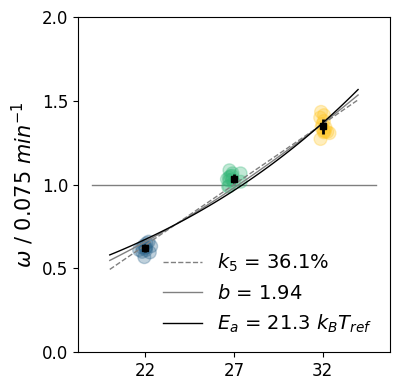

v_f: [0.1665364  0.24861063 0.36325426] with errs [0.03340369 0.03375572 0.03255122]
Tc v_f: 13.774869882534155
Allometric model: [0.25202306 2.09917437]
Arrhenius model: [ 0.24755088 23.10443618]
v_f p(27) = 0.2588525799997846 ; k = 0.0756136227861641


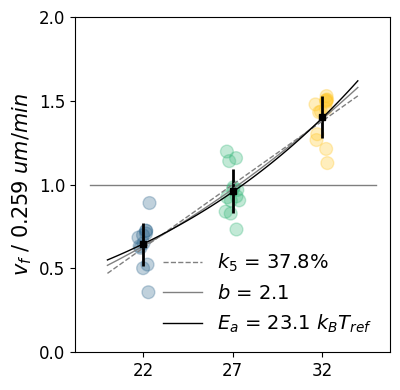

v_tb: [0.12627692 0.19102931 0.19936263] with errs [0.02338132 0.04319918 0.0369247 ]
Tc v_tb: 2.148654817405463
Allometric model: [0.17148373 1.05399805]
Arrhenius model: [ 0.16993449 11.47091073]
v_tb p(27) = 0.17139591095190523 ; k = 0.04023927045608722


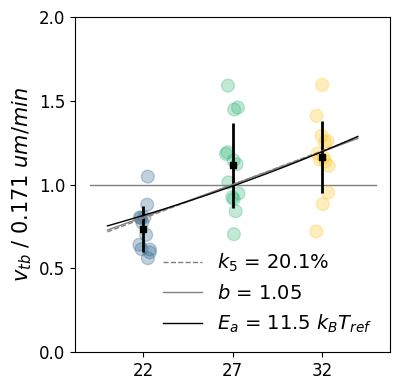

alpha: [0.00371167 0.00683978 0.00645191] with errs [0.00091824 0.00177202 0.00143728]
Tc alpha: 2.782860833650541
Allometric model: [0.00556431 1.04921096]
Arrhenius model: [5.51735165e-03 1.12064225e+01]
alpha p(27) = 0.0055546359668898525 ; k = 0.04129306905869114


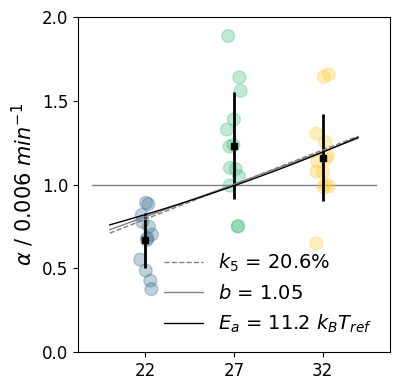

beta: [0.03003586 0.03656284 0.03263418] with errs [0.00846172 0.00831901 0.00593276]
Tc beta: -237.91916406092872
beta p(27) = 0.03272981171133816 ; k = 0.0037747363560683696


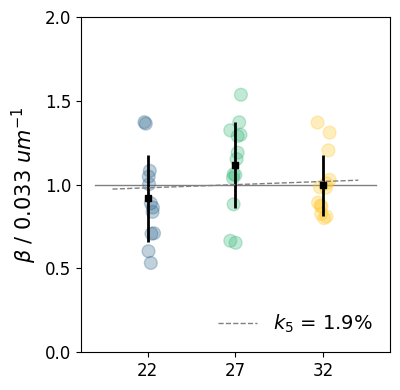

lambda_f: [22.42500186 20.09298789 22.5362732 ] with errs [4.22438492 2.90912279 1.96192001]
Tc lambda_f: -1242.7210126440407
lambda_f p(27) = 21.66097414175992 ; k = 0.0007875745853159293


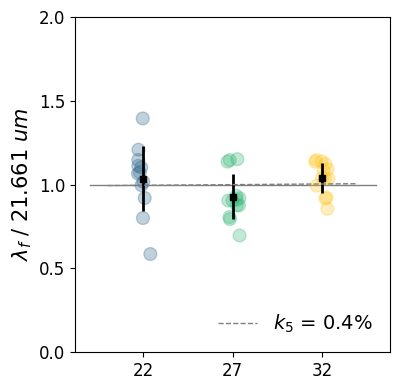

lambda_tb: [17.01718792 15.43676646 12.35003023] with errs [2.97021975 3.51819605 2.19600455]
Tc lambda_tb: 57.779695937402195
lambda_tb p(27) = 14.89267046060681 ; k = -0.03248894992444816


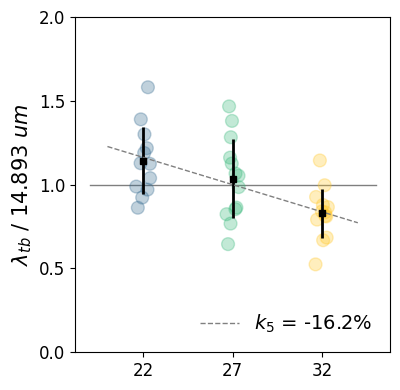

alpha_c: [0.50037662 0.55288793 0.39967277] with errs [0.12169919 0.14434352 0.08572361]
Tc alpha_c: 64.43024535249491
alpha_c p(27) = 0.4774560840390221 ; k = -0.026716362411804067


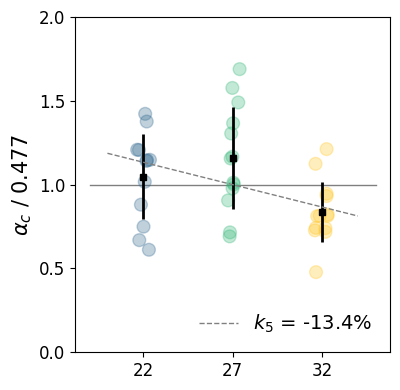

resid_cycle: [3.84093966 2.9390324  2.76343696] with errs [0.95900516 0.93925953 1.51383869]
Tc resid_cycle: 75.52186322607201
resid_cycle p(27) = 3.3032605415970995 ; k = -0.020609266287669598


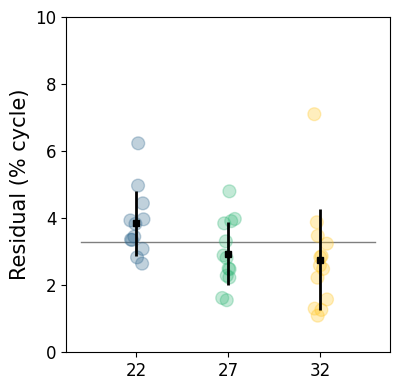

In [6]:
ylims = {
    '(U0,U0)': (0.9, 1.1),
    '(U1,U1)': (0.9, 1.1),
    '(V0,V0)': (0.9, 1.1),
    '(V1,V1)': (0.9, 1.1),
    '|(U0,U1)|': (-0.1, 0.1),
    '|(V0,V1)|': (-0.1, 0.1),
    'resid_cycle': (0., 10.),
    'kappa_c': (-0.1, 0.25),
    'kappa': (-0.001, 0.004),
    'deltaphi_init': (0., 3.),
}


plot_results(df, ('omega0',), ylims, print_avg=True, k5=True, all_fit=True)
plot_results(df, ('v_f',), ylims, print_avg=True, k5=True, all_fit=True)
plot_results(df, ('v_tb',), ylims, print_avg=True, k5=True, all_fit=True)
plot_results(df, ('alpha',), ylims, print_avg=True, all_fit=True)

plot_results(df, ('beta',), ylims, print_avg=True)

plot_results(df, ('lambda_f',), ylims, print_avg=True)
plot_results(df, ('lambda_tb',), ylims, print_avg=True)
plot_results(df, ('alpha_c',), ylims, print_avg=True)

plot_results(df, ('resid_cycle',), ylims, print_avg=True, plot_k=False)


# Temperature sensitivity

{'omega0': (0.07224855346857434, 0.0017268442275138107), 'v_f': (0.0756136227861641, 0.005562554836153023), 'v_tb': (0.04023927045608722, 0.0092288294059912), 'alpha': (0.04129306905869114, 0.012526331155703372), 'beta': (0.0037747363560683696, 0.010164437740374939), 'lambda_f': (0.0007875745853159293, 0.006041529245597209), 'lambda_tb': (-0.03248894992444816, 0.008026419726584601), 'alpha_c': (-0.026716362411804067, 0.01098542611256761), 'resid_cycle': (-0.020609266287669598, 0.015650372188159793), 'r': (0.0670020053594601, 0.00627461768323679)}
v_f
omega0
r
alpha
v_tb
lambda_tb
alpha_c
beta
lambda_f


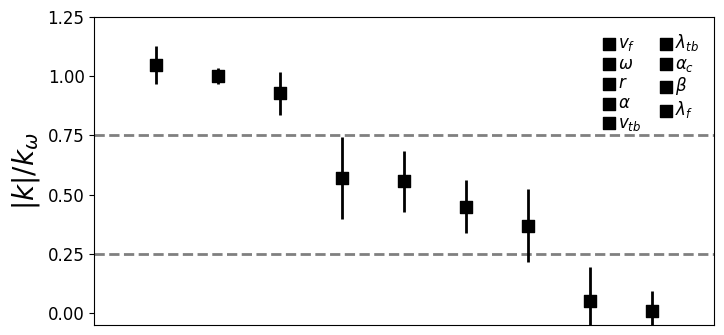

In [7]:
k_coef['r'] = (0.0670020053594601, 0.00627461768323679)
symbols['r'] = '$r$'
print(k_coef)
k_coef = dict(sorted(k_coef.items(), key=lambda item: -np.abs(item[1][0])))


par_exclude = ['a1_cycle', 'A1', 'C1', 'deltaphi_psm50_change', 'omegaA', 'omega_front', 'omega_tb', 'Atemp_stretch',
              'deltaphi_change_cycle', 'a1_stretch_cycle', 'b1_stretch', 'b1', 'v_f/v_tb', 'sep 0+1', 'avg_deltaphi_svd',
              '(U0,U0)', '|(U0,U1)|', '(U1,U1)', '(V0,V0)', '|(V0,V1)|', '(V1,V1)', 's1/s0', 'ss',
               'min PSM', 'Atemp_avg', 'Abeta', 'v_s', 'Abeta*beta', 'mean PSM', 'p', 'q',
               'Full quad fit resid (% cycle)', 'Full fit resid (% cycle)', 'T0*v_tb', 'T0', 'Fit resid (% cycle)',
               'Amp', 'resid_cycle', 'deltaphi_init', 'x0', 'kappa_c', 'kappa']

for par in par_exclude:
    if par in k_coef.keys():
        del k_coef[par]

plt.figure(figsize=(8.,4))
for i, par in enumerate(k_coef.keys()):
    print(par)

    k_norm = np.abs(k_coef[par][0]/k_coef['omega0'][0])
    k_norm_err = np.sqrt( (k_coef[par][1]/k_coef['omega0'][0])**2 + (k_norm/k_coef['omega0'][0]*k_coef['omega0'][1])**2 )
    plt.errorbar(i, k_norm, yerr=k_norm_err, fmt="", c='k', alpha=1, zorder=1)
    if i < len(k_coef.keys())/2:
        marker = '.'
    else:
        marker = '.'
    if par in symbols:
        label = symbols[par]
    else:
        label = par
    plt.scatter(i, k_norm, label=label, s=80, marker='s', alpha=1., c='k')


plt.legend(ncol=2, fontsize=12, frameon=False, labelspacing=0.1, columnspacing=1., handletextpad=0.05, handlelength=1.)
plt.hlines(0.25, -1, len(k_coef.keys()), linestyle='--', color='grey', alpha=1, zorder=0)
plt.hlines(0.75, -1, len(k_coef.keys()), linestyle='--', color='grey', alpha=1, zorder=0)

plt.xlim([-1, len(k_coef.keys())])
plt.xticks([])
plt.yticks(np.arange(0, 2.1, 0.25))
plt.ylabel(r'$|k|/k_\omega$', fontsize=20)
plt.ylim((-0.05, 1.25))

plt.show()

# Plot all modes

TE_22C_14ss 20210301 1
TE_22C_14ss 20210301 2
TE_22C_14ss 20210301 4
TE_22C_14ss 20210301 5
TE_22C_14ss 20210301 6
TE_22C_14ss 20210301 7
TE_22C_15ss 20200817 1
TE_22C_15ss 20200817 4
TE_22C_15ss 20200817 6
TE_22C_15ss 20200817 7
TE_22C_15ss 20200817 8
TE_22C_15ss 20200817 9
TE_27C_14ss 20200815 1
TE_27C_14ss 20200815 2
TE_27C_14ss 20200815 3
TE_27C_14ss 20210310 2
TE_27C_14ss 20210310 3
TE_27C_14ss 20210310 4
TE_27C_14ss 20210310 5
TE_27C_14ss 20210310 6
TE_27C_14ss 20210310 7
TE_27C_17ss 20200815 6
TE_27C_17ss 20200815 8
TE_27C_17ss 20200815 9
TE_27C_17ss 20200815 10
TE_32C_14ss_5dt 20220428 1
TE_32C_14ss_5dt 20220428 2
TE_32C_14ss_5dt 20220428 3
TE_32C_14ss_5dt 20220428 4
TE_32C_14ss_5dt 20220428 5
TE_32C_14ss_5dt 20220429 1
TE_32C_14ss_5dt 20220429 2
TE_32C_14ss_5dt 20220429 3
TE_32C_14ss_5dt 20220429 4
TE_32C_14ss_5dt 20220429 5
TE_32C_14ss_5dt 20220430 1
TE_32C_14ss_5dt 20220430 2
TE_32C_14ss_5dt 20220430 3
TE_32C_14ss_5dt 20220430 4
TE_32C_14ss_5dt 20220430 5


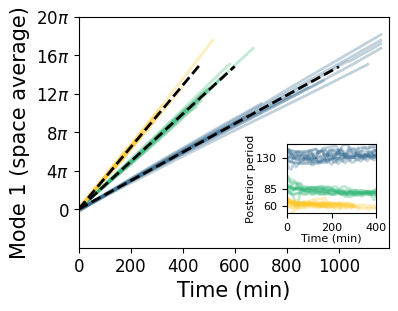

In [8]:
plt.figure(figsize=(4,3))
plt.ylim((-4*np.pi, 20*np.pi))
plt.xlim((0, 1190))
plt.yticks(np.arange(0, 20.1, 4)*np.pi,labels = ('0', '$4\pi$', '$8\pi$', '$12\pi$', '$16\pi$', '$20\pi$',))
plt.xlabel('Time (min)', fontsize=15)
plt.ylabel('Mode 1 (space average)', fontsize=15)

ax = plt.gca()
ax1 = inset_axes(ax, width="30%", height="30%", loc="lower right", bbox_to_anchor=(0., 0.15, 0.96, 1),  bbox_transform=ax.transAxes,
    borderpad=0)
ax1.set_xlabel('Time (min)', fontsize=8, labelpad=0)
ax1.set_ylabel('Posterior period', fontsize=8, labelpad=0)
ax1.set_xticks((0, 200, 400), labels=(0, 200, 400), fontsize=8)
ax1.set_yticks((0, 60, 85, 130), labels=(0, '60', '85' , 130), fontsize=8, rotation=0)
ax1.set_xlim((0, 400))
ax1.set_ylim((50, 150))



for index in df.index:
    exp, date, sample = index
    print(exp, date, sample)
    osc = np.loadtxt('SVD_results/' +exp+ '/mode0_space_avg_' + str(date) + '_P' + str(sample) + '.txt')
    osc-= df.loc[index, 'C0']
    period = 2*np.pi/np.gradient(osc, df.loc[index, 'dt'])
    if df.loc[index, 'good_fit']:
        ax.plot(np.arange(len(osc))*df.loc[index, 'dt'], osc, c = df.loc[index, 'color'], alpha=0.3)
        ax1.plot(np.arange(len(osc))*df.loc[index, 'dt'], period, c = df.loc[index, 'color'], alpha=0.3)
        # plt.plot(np.arange(0, 500, 100), df.loc[index, 'omega0']* np.arange(0, 500, 100), '--', c = df.loc[index, 'color'])


# for index in df_hilbert.index[:]:
#     if index[0] == 'hilbert/6h':
#         exp, date, sample = index
#         if index[1:] == ('221129', 2):
#             continue
#         gradient = np.loadtxt('SVD_results_sigmoid/' +exp+ '/mode1_time_avg_' + date + '_P' + str(sample) + '.txt')
#         # gradient-= np.mean(gradient[:5])
#         xx = np.arange(len(gradient))*2
#         gradient -= 1.
#         if df_hilbert.loc[index, 'good_fit']:
#             plt.plot(xx, -gradient, c = 'indianred', alpha=0.5)


tt = np.arange(1000)
fit = 0.04658 * tt
ax.plot(tt, fit, '--', c = 'k', alpha = 1)

tt = np.arange(600)
fit = 0.07786 * tt
ax.plot(tt, fit, '--', c = 'k', alpha = 1)

tt = np.arange(470)
fit = 0.1013 * tt
ax.plot(tt, fit, '--', c = 'k', alpha = 1)
plt.show()

In [9]:
idx = (df['good_fit'] == True)

print(np.nanmean(df['beta'][idx]))
print(np.nanmean(df['x0'][idx]))
print(np.nanmean(df['psm0'][idx]))
print(np.nanmean((df['x0']/df['psm0'])[idx]))

print(np.nanmean(df['omega0'][idx]))
print(np.nanmean(df['v_tb'][idx]))

0.033157673203150974
117.03869132490654
176.85789473684213
0.6647490423986725
0.07600250629835706
0.17343205948395787


Excluded ('TE_32C_14ss_5dt', 20220430, 2) 0.0148877107203108
Excluded ('TE_32C_14ss_5dt', 20220429, 5) 0.0361663721663904


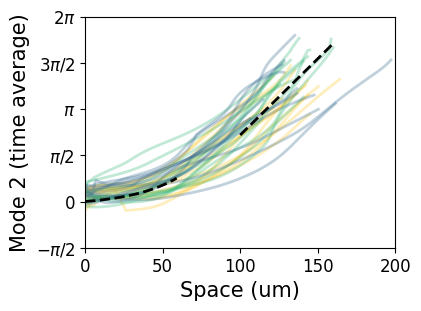

In [10]:
plt.figure(figsize=(4,3))
for index in df.index[::-1]:
    exp, date, sample = index
    gradient = np.loadtxt('SVD_results/' +exp+ '/mode1_time_avg_' + str(date) + '_P' + str(sample) + '.txt')
    gradient-= df.loc[index, 'C1']
    if df.loc[index, 'good_fit']:
        plt.plot(np.arange(len(gradient))*1.38, -gradient, c = df.loc[index, 'color'], alpha=0.3)
    else:
        print('Excluded', index, df.loc[index, 'beta'])

# #
# xx = np.arange(200)*1.38
# fit = 2*np.pi/(1 + np.exp(-0.033*(xx-117)))
# fit -= fit[0]
# plt.plot(xx, fit, c = 'k', alpha = 1)
#

# #
# fit = 0.4* np.exp(0.017*(xx))
# fit -= fit[0]
# plt.plot(xx, fit, '--', c = 'k', alpha = 1)

xx = np.arange(100, 160, 1)
fit = np.pi + (0.033 * np.pi)/2 *(xx-117)
plt.plot(xx, fit, '--', c = 'k', alpha = 1)
#
#
xx = np.arange(0, 60, 1)
fit = 2*np.pi * np.exp(0.033*(xx-117))
fit -= fit[0]
plt.plot(xx, fit, '--', c = 'k', alpha = 1)



plt.ylim((-1, 2*np.pi))
plt.xlim((0, 200))
plt.yticks(np.arange(-0.5, 2.1, 0.5)*np.pi, labels = ('$-\pi/2$', '$0$', '$\pi/2$', '$\pi$', '$3\pi/2$', '$2\pi$'))
plt.xlabel('Space (um)', fontsize=15)
plt.ylabel('Mode 2 (time average)', fontsize=15)
plt.show()

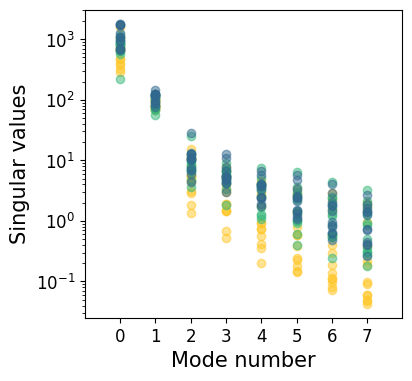

In [11]:
n = 8
plt.figure(figsize=(4.1,4))
for index in df.index[::-1]:
    exp, date, sample = index
    s = np.loadtxt('SVD_results/' +exp+ '/singular_values_' + str(date) + '_P' + str(sample) + '.txt')
    if df.loc[index, 'good_fit']:
        plt.scatter(np.arange(len(s[:n])), s[:n], c = df.loc[index, 'color'], alpha=0.5,marker='o')
plt.yscale('log', base=10)
plt.xlim((-1, n))
plt.xticks(np.arange(n))
plt.xlabel('Mode number', fontsize=15)
plt.ylabel('Singular values', fontsize=15)
plt.show()


Excluded ('TE_32C_14ss_5dt', 20220430, 2) 0.0148877107203108
Excluded ('TE_32C_14ss_5dt', 20220429, 5) 0.0361663721663904


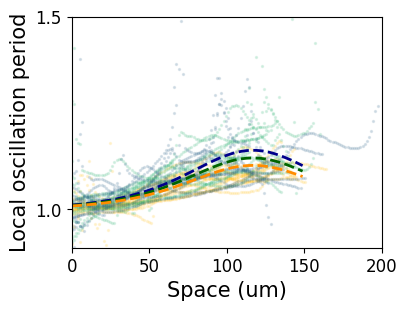

In [12]:
plt.figure(figsize=(4,3))
for index in df.index[::-1]:
    exp, date, sample = index
    gradient = np.loadtxt('SVD_results/' +exp+ '/mode1_time_avg_' + str(date) + '_P' + str(sample) + '.txt')
    gradient-= df.loc[index, 'C1']
    gradient = np.abs(gradient)
    deriv = np.gradient(gradient, 1.38)
    omega0 = df.loc[index, 'omega0']
    omega = df.loc[index, 'omega0'] - df.loc[index, 'v_tb'] * deriv
    period = 2*np.pi/omega
    T0 = 2*np.pi / df.loc[index, 'omega0']

    # omega_analytic = df.loc[index, 'omega0'] - df.loc[index, 'alpha'] * gradient * (1 - gradient/2/np.pi)
    # T_analytic = 2*np.pi/omega_analytic

    T_norm = period/T0

    if df.loc[index, 'good_fit']:
        # dist = np.abs(period - T_analytic)**2/T0**2
        # plt.plot(np.arange(len(gradient))*1.38, omega/omega0, c = df.loc[index, 'color'], alpha=0.3)
        plt.scatter((np.arange(len(gradient))*1.38), T_norm, c = df.loc[index, 'color'], alpha=0.15, s=2)
        # plt.plot(np.arange(len(gradient))*1.38, T_analytic/T0,'--', c = df.loc[index, 'color'], alpha=0.5)
        # plt.hlines(1 - df.loc[index, 'alpha']*np.pi/omega0/2, 0, 125, color=df.loc[index, 'color'])
    else:
        print('Excluded', index, df.loc[index, 'beta'])
    plt.ylim((0.8, 1.2))


xx = np.arange(150)
sig = 1/(1 + np.exp(-0.033*(xx-117)))
omega_analytic = 1 - 0.47*(1+0.13) * sig * (1 - sig)
T_analytic = 1/omega_analytic
plt.plot(xx, T_analytic, '--', c = 'darkblue', alpha = 1)

omega_analytic = 1 - 0.47 * sig * (1 - sig)
T_analytic = 1/omega_analytic
plt.plot(xx, T_analytic, '--', c = 'darkgreen', alpha = 1)
#
omega_analytic = 1 - 0.47*(1-0.13) * sig * (1 - sig)
T_analytic = 1/omega_analytic
plt.plot(xx, T_analytic, '--', c = 'darkorange', alpha = 1)


plt.yticks(np.arange(0.5, 2.1, 0.5))
plt.ylim((0.9, 1.5))
plt.xlim((0, 200))
plt.xlabel('Space (um)', fontsize=15)
plt.ylabel('Local oscillation period', fontsize=15)
plt.show()

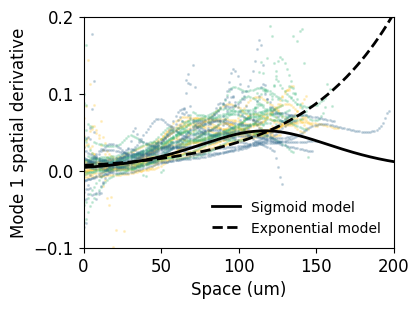

In [13]:
plt.figure(figsize=(4,3))

for index in df.index[::-1]:
    exp, date, sample = index
    gradient = np.loadtxt('SVD_results/' +exp+ '/mode1_time_avg_' + str(date) + '_P' + str(sample) + '.txt')
    if df.loc[index, 'good_fit']:
        plt.scatter(np.arange(len(gradient))*1.38, np.gradient(-gradient), c = df.loc[index, 'color'], alpha=0.2, s=1.5)


# for index in df_hilbert.index[:]:
#     if index[0] == 'hilbert/6h':
#         exp, date, sample = index
#         if index[1:] == ('221129', 2):
#             continue
#         gradient = np.loadtxt('SVD_results_sigmoid/' +exp+ '/mode1_time_avg_' + date + '_P' + str(sample) + '.txt')
#         xx = np.arange(len(gradient))*2
#         if df_hilbert.loc[index, 'good_fit']:
#             plt.scatter(xx, np.gradient(-gradient)/2, c = 'indianred', alpha=0.5, s=2)


xx = np.arange(200)*1.38
fit = 2*np.pi* 0.033* np.exp(-0.033*(xx-117))/(1 + np.exp(-0.033*(xx-117)))**2
plt.plot(xx, fit, c = 'k', alpha = 1, label = 'Sigmoid model')
#
fit = 0.4* 0.017 * np.exp(0.017*(xx))
plt.plot(xx, fit, '--', c = 'k', alpha = 1, label='Exponential model')

plt.ylim((-0.1, 0.2))
plt.xlim((0, 200))
plt.ylabel('Mode 1 spatial derivative')
plt.xlabel('Space (um)')
plt.legend(frameon=False, fontsize=10)
plt.show()

In [14]:
for T in (22, 27, 32):

    idx = df['Temp'] == T
    print(T)
    print(np.nanmean(df['beta'][idx]))
    print(np.nanmean(df['alpha'][idx]))
    print(np.nanmean(df['x0'][idx]))
    print(np.nanmean(df['psm0'][idx]))
    print(np.nanmean(df['psm_f'][idx]))
    print(np.nanmean((df['x0']/df['psm0'])[idx]))
    print()

print()

print('6h')
idx = df_hilbert.index.get_level_values('Exp')=='hilbert/6h'
print(np.nanmean(df_hilbert['beta'][idx]))
print(np.nanmean(df_hilbert['alpha'][idx]))

print(np.nanmean(df_hilbert['x0'][idx]))
print(np.nanmean(df_hilbert['psm0'][idx]))
print(np.nanmean((df_hilbert['x0']/df_hilbert['psm0'])[idx]))



22
0.03003585553186025
0.003711674687473434
118.91082928003004
183.99999999999997
140.53
0.6458999271732403

27
0.036562840871659966
0.006839783252797046
111.91310802562725
167.19230769230765
138.5307692307692
0.6719592733629146

32
0.03168656445950236
0.006144578642546767
109.24274275882527
179.676
137.07999999999996
0.6125156982007555


6h
0.03464256106718776
0.007327379119647887
139.11098805808027
209.76
0.6657097145359085
